In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import joblib

In [53]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CKD Project/cleaned_data_ckd.csv')
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,1,1,0,0,121,...,44,7800,5.200,1,1,0,1,0,0,1
1,7,50,1.020,4,0,1,1,0,0,96,...,38,6000,5.334,0,0,0,1,0,0,1
2,62,80,1.010,2,3,1,1,0,0,423,...,31,7500,3.829,0,1,0,0,0,1,1
3,48,70,1.005,4,0,1,0,1,0,117,...,32,6700,3.900,1,0,0,0,1,1,1
4,51,80,1.010,2,0,1,1,0,0,106,...,35,7300,4.600,0,0,0,1,0,0,1


In [57]:
X = df.drop(columns=['class'])
y = df['class'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [58]:
print(y_train.value_counts())
print(y_test.value_counts())

class
1    200
0    120
Name: count, dtype: int64
class
1    50
0    30
Name: count, dtype: int64


In [32]:
NUM_COLS = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
scaler = StandardScaler()
X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

In [59]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100,random_state=42, eval_metric='logloss',verbosity=0)
voting = VotingClassifier(
    estimators=[
        ('rf',  rf),
        ('gb',  gb),
        ('ada', ada),
        ('xgb', xgb)
    ],
    voting='soft'
)

models = {
    'Random Forest'     : rf,
    'Gradient Boosting' : gb,
    'AdaBoost'          : ada,
    'XGBoost'           : xgb,
    'Voting Classifier' : voting,
}
for name,model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(name)
    print("Acuracy:",accuracy_score(y_test,y_pred))
    print("classification Report:\n",classification_report(y_test,y_pred))



Random Forest
Acuracy: 1.0
classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Gradient Boosting
Acuracy: 1.0
classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

AdaBoost
Acuracy: 0.9875
classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy               

In [60]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.pipeline import Pipeline

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    accuracy = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy')
    precision = cross_val_score(pipe, X, y, cv=kf, scoring='precision')
    recall = cross_val_score(pipe, X, y, cv=kf, scoring='recall')
    f1 = cross_val_score(pipe, X, y, cv=kf, scoring='f1')
    print("\n",name)
    print("Acuracy:",accuracy.mean())
    print("precision:",precision.mean())
    print("recall:",recall.mean())
    print("f1:",f1.mean())


 Random Forest
Acuracy: 0.9949999999999999
precision: 0.996078431372549
recall: 0.9960000000000001
f1: 0.9959995999599961

 Gradient Boosting
Acuracy: 0.9949999999999999
precision: 0.996078431372549
recall: 0.9960000000000001
f1: 0.9959995999599961

 AdaBoost
Acuracy: 0.9949999999999999
precision: 1.0
recall: 0.992
f1: 0.995959595959596

 XGBoost
Acuracy: 0.9949999999999999
precision: 1.0
recall: 0.992
f1: 0.995959595959596

 Voting Classifier
Acuracy: 0.9949999999999999
precision: 0.996078431372549
recall: 0.9960000000000001
f1: 0.9959995999599961


**Hyperparameter Tunning**

In [61]:
param_grids = {

    'Random Forest': (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {
            'n_estimators'      : [50, 100, 200, 300],
            'max_depth'         : [None, 5, 10, 20],
            'min_samples_split' : [2, 5, 10],
            'min_samples_leaf'  : [1, 2, 4],
            'max_features'      : ['sqrt', 'log2'],
        }
    ),

    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators'      : [50, 100, 200, 250],
            'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
            'max_depth'         : [3, 5, 7],
            'subsample'         : [0.7, 0.8, 1.0],
            'min_samples_split' : [2, 5],
        }
    ),

    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {
            'n_estimators'  : [50, 100, 200, 250],
            'learning_rate' : [0.01, 0.1, 0.5, 1.0],
        }
    ),

    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        {
            'n_estimators'    : [50, 100, 200, 250],
            'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
            'max_depth'       : [3, 5, 7],
            'subsample'       : [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'reg_alpha'       : [0, 0.1, 0.5],
            'reg_lambda'      : [1, 1.5, 2],
        }
    ),
}

In [62]:
best_models    = {}
tuning_results = {}

for name, (estimator, params) in param_grids.items():

    search = GridSearchCV(
        estimator,
        params,
        scoring='f1',
        cv=kf,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    tuning_results[name] = search.best_score_

In [63]:
best_models

{'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=300,
                        random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(n_estimators=250, random_state=42, subsample=0.8),
 'AdaBoost': AdaBoostClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_

In [65]:
tuning_results

{'Random Forest': np.float64(0.9949992186279106),
 'Gradient Boosting': np.float64(0.9924683544303796),
 'AdaBoost': np.float64(0.9874683544303797),
 'XGBoost': np.float64(0.9900609470229723)}

In [64]:
best_models.update({"Voting": VotingClassifier(
    estimators=[
        ('rf',  best_models['Random Forest']),
        ('gb',  best_models['Gradient Boosting']),
        ('ada', best_models['AdaBoost']),
        ('xgb', best_models['XGBoost'])
    ], voting='soft'
)})
best_models['Voting'].fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(n_estimators=250,
                                                         random_state=42,
                                                         subsample=0.8)),
                             ('ada', AdaBoostClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=No...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=250, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [68]:
cv_results = []

for name, model in best_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    accuracy = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy').mean()
    precision = cross_val_score(pipe, X, y, cv=kf, scoring='precision').mean()
    recall = cross_val_score(pipe, X, y, cv=kf, scoring='recall').mean()
    f1 = cross_val_score(pipe, X, y, cv=kf, scoring='f1').mean()

    res = {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    cv_results.append(res)

    print(f"\nModel: {name}")
    print(f"Accuracy:  {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall:    {recall}")
    print(f"F1-Score:  {f1}")


Model: Random Forest
Accuracy:  0.9949999999999999
Precision: 0.996078431372549
Recall:    0.9960000000000001
F1-Score:  0.9959995999599961

Model: Gradient Boosting
Accuracy:  0.9925
Precision: 0.996078431372549
Recall:    0.992
F1-Score:  0.9939793979397941

Model: AdaBoost
Accuracy:  0.99
Precision: 0.996078431372549
Recall:    0.9879999999999999
F1-Score:  0.9919179673069347

Model: XGBoost
Accuracy:  0.9949999999999999
Precision: 1.0
Recall:    0.992
F1-Score:  0.9959183673469388

Model: Voting
Accuracy:  0.99
Precision: 0.996078431372549
Recall:    0.9879999999999999
F1-Score:  0.9919179673069347


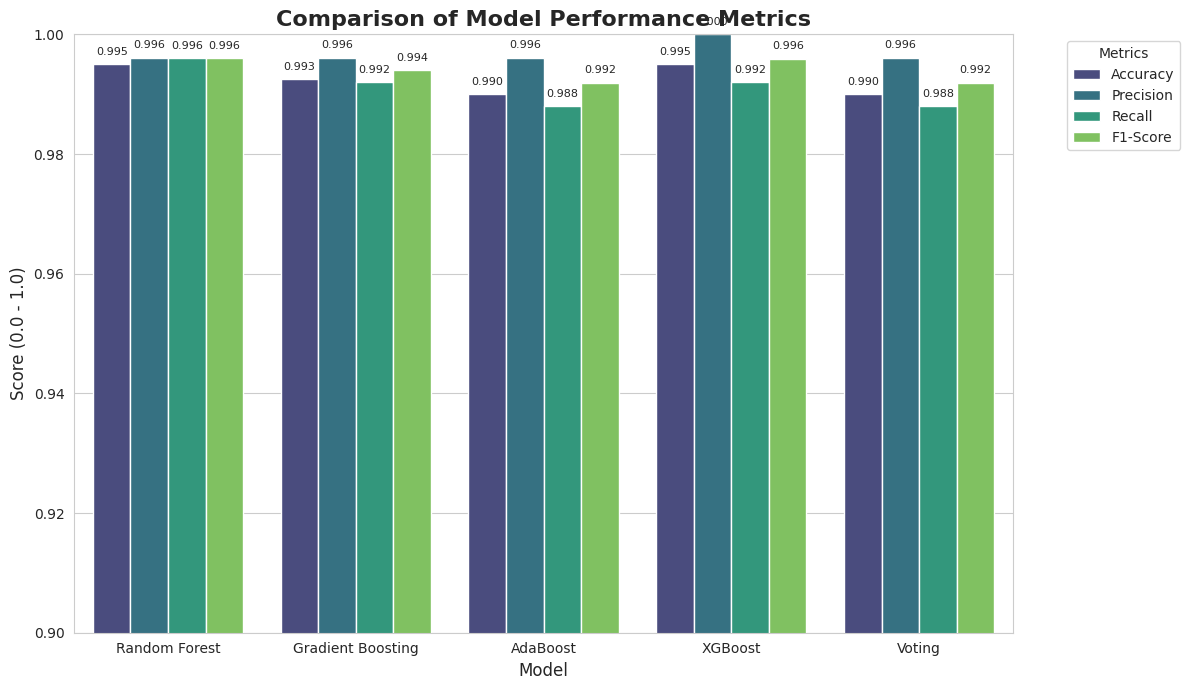

In [91]:
results_df = pd.DataFrame(cv_results)

results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plot = sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Comparison of Model Performance Metrics', fontsize=16, fontweight='bold')
plt.ylim(0.9, 1.0)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Metrics')

for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.3f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontsize=8, rotation=0)

plt.tight_layout()
plt.savefig('model_performance.png')
plt.show()

## Model Comparison: ROC AUC Curves and Confusion Matrices

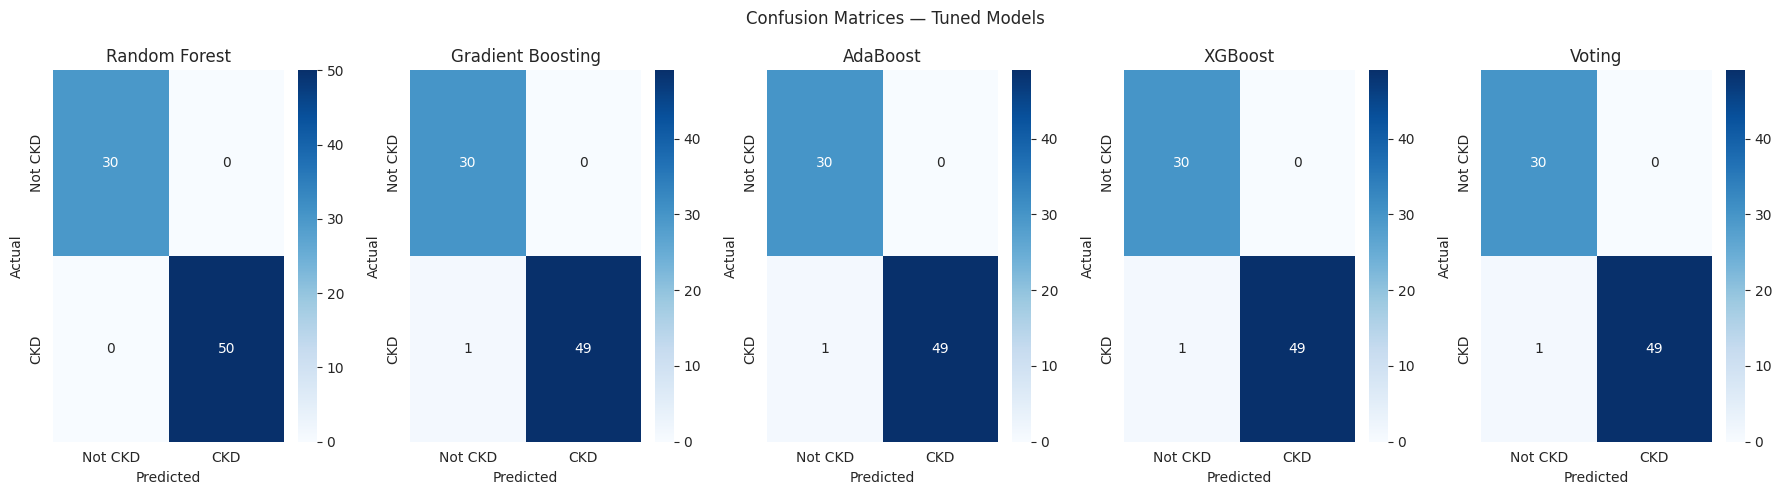

In [71]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Tuned Models')

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'])

    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Comparative ROC AUC Curves for All Models

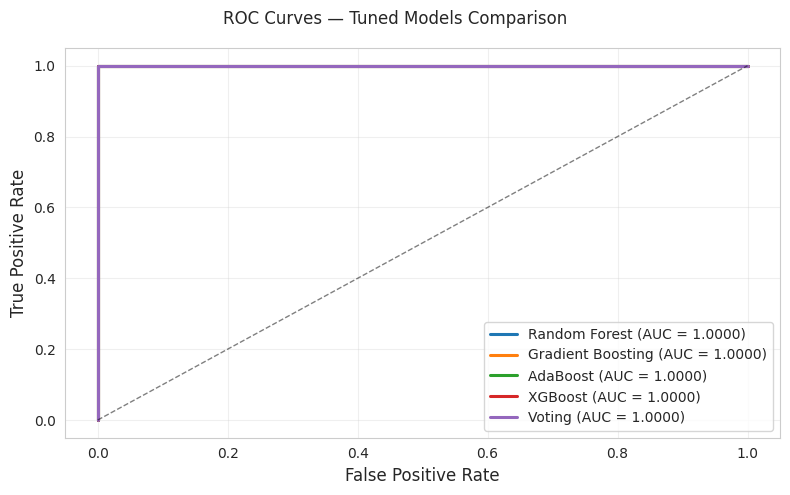

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('ROC Curves — Tuned Models Comparison')

for i, (name, model) in enumerate(best_models.items()):

        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, linewidth=2.2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

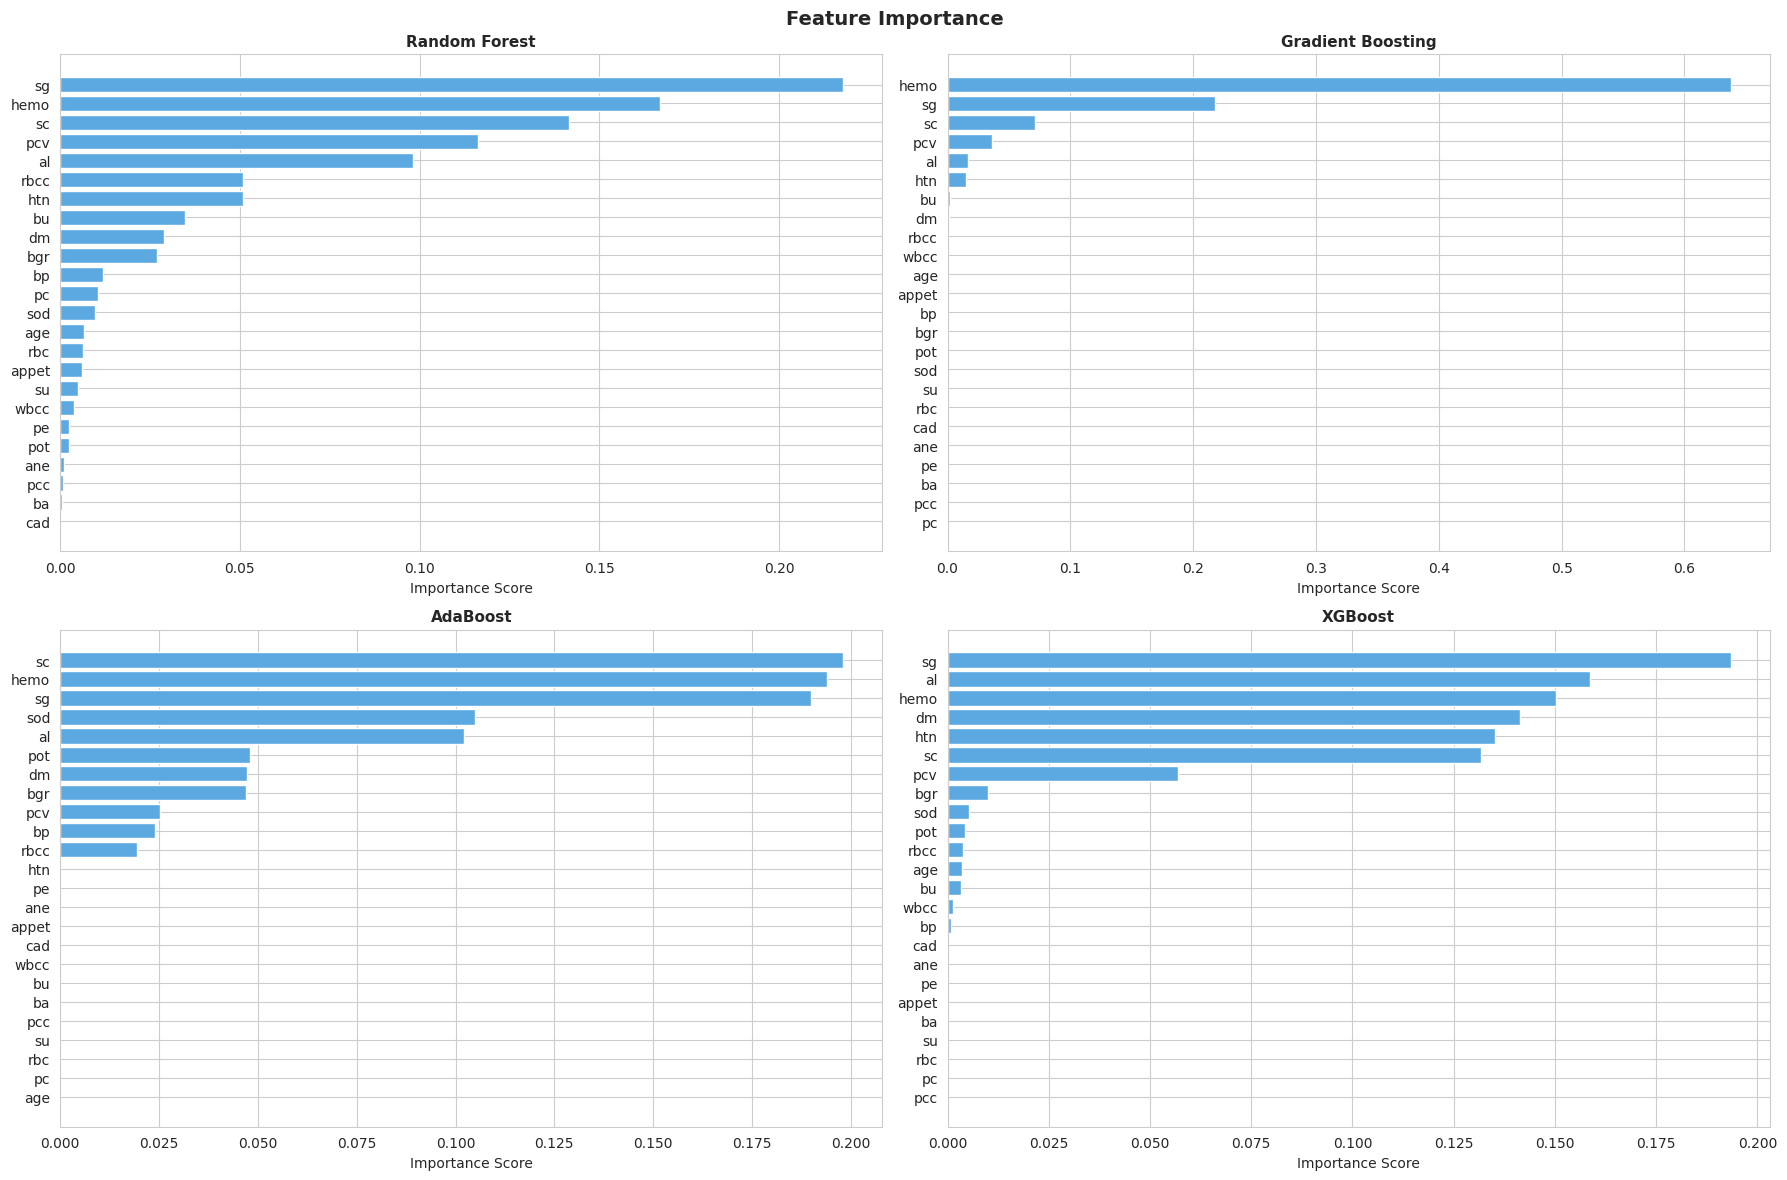

In [74]:
importance_models = {
    name: model for name, model in best_models.items()
    if hasattr(model, 'feature_importances_')
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, best_models.items()):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)

    ax.barh(importances.index, importances.values, color='#5CA8E0')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [75]:
required = ["sg", "hemo", "sc", "al", "htn", "dm", "age", "bp", "su", "bgr", "bu", "sod", "pot", "pcv","rc"]
optional = [ "appet", "wc", "rbc", "pc", "pcc", "ba", "cad", "pe", "ane"]

In [76]:
for name, model in best_models.items():
    path = f'/content/drive/MyDrive/Colab Notebooks/CKD Project/{name}.pkl'
    joblib.dump(model, path)

In [81]:
loaded_voting  = joblib.load('/content/drive/MyDrive/Colab Notebooks/CKD Project/Voting.pkl')

# ─── Example: predict a single new patient ────────────────────────────────────
print("="*55)
print("EXAMPLE — Single Patient Prediction")
print("="*55)

new_patient = pd.DataFrame([{
    'age': 45, 'bp': 80,  'sg': 1.020, 'al': 1,   'su': 0,
    'bgr': 121,'bu': 36,  'sc': 1.2,   'sod': 138, 'pot': 4.4,
    'hemo': 15.4, 'pcv': 44, 'wbcc': 7800, 'rbcc': 5.2,
    'rbc': 1, 'pc': 1, 'pcc': 0, 'ba': 0,
    'htn': 0, 'dm': 0, 'cad': 0, 'appet': 1, 'pe': 0, 'ane': 0,
}])


new_patient = new_patient.reindex(columns=X_train.columns, fill_value=0)

prediction = loaded_voting.predict(new_patient)[0]
confidence = loaded_voting.predict_proba(new_patient)[0]

print(f"\nPrediction : {'CKD' if prediction == 1 else 'Not CKD'}")
print(f"Confidence : Not CKD = {confidence[0]:.4f} | CKD = {confidence[1]:.4f}")

EXAMPLE — Single Patient Prediction

Prediction : CKD
Confidence : Not CKD = 0.3713 | CKD = 0.6287
